# Appendix A Dataset: House_Price

## Linear Regression Models

In [4]:
import pandas as pd

myData = pd.read_excel('Appendix_A_data.xlsx', sheet_name = 'House_Price')

myData.head()

,Record,Sale_amount,Sale_date,Beds,Baths,Sqft_home,Sqft_lot,Type,Build_year,Town,University
0,1,295000,2016-05-31,5,3.00,2020,38332.8,Single Family,1976,"Ames, IA",Iowa State University
1,2,240000,2016-06-20,4,2.00,1498,54014.4,Single Family,2002,"Ames, IA",Iowa State University
2,3,385000,2016-05-31,5,4.00,4000,85813.2,Single Family,2001,"Ames, IA",Iowa State University
3,4,268000,2016-04-12,3,2.50,2283,118918.8,Single Family,1972,"Ames, IA",Iowa State University
4,5,186000,2016-04-05,3,1.25,1527,15681.6,Single Family,1975,"Ames, IA",Iowa State University


In [5]:
# Filter data for Iowa State University
myData = myData.query("University =='Iowa State University'")

# Convert house type into dummy variable, Single Family = 1, Non Single Family = 0
myData['Type'] = myData['Type'].apply(lambda x: 1 if x == 'Single Family' else 0)

# Determining age of home
from datetime import datetime
myData['Age'] = datetime.now().year - myData['Build_year']

myData.head()

,Record,Sale_amount,Sale_date,Beds,Baths,Sqft_home,Sqft_lot,Type,Build_year,Town,University,Age
0,1,295000,2016-05-31,5,3.00,2020,38332.8,1,1976,"Ames, IA",Iowa State University,49
1,2,240000,2016-06-20,4,2.00,1498,54014.4,1,2002,"Ames, IA",Iowa State University,23
2,3,385000,2016-05-31,5,4.00,4000,85813.2,1,2001,"Ames, IA",Iowa State University,24
3,4,268000,2016-04-12,3,2.50,2283,118918.8,1,1972,"Ames, IA",Iowa State University,53
4,5,186000,2016-04-05,3,1.25,1527,15681.6,1,1975,"Ames, IA",Iowa State University,50


In [7]:
# Descriptive statistics for Ames dataset
desc_stats = myData[['Sale_amount', 'Beds', 'Baths', 'Sqft_home', 'Sqft_lot', 'Age']].describe().T
desc_stats
desc_stats_rounded = desc_stats.round(2)
desc_stats_rounded



,count,mean,std,min,25%,50%,75%,max
Sale_amount,211.0,229548.42,110646.75,51000.0,160000.0,215000.0,265050.0,925000.0
Beds,211.0,3.31,0.90,1.0,3.0,3.0,4.0,6.0
Baths,211.0,2.35,0.87,1.0,2.0,2.0,3.0,5.0
Sqft_home,211.0,1645.29,716.55,630.0,1218.0,1521.0,1916.0,6974.0
Sqft_lot,211.0,19102.07,40308.16,1015.0,8094.0,10159.0,13068.0,413820.0
Age,211.0,54.80,30.48,9.0,29.0,52.0,72.0,145.0


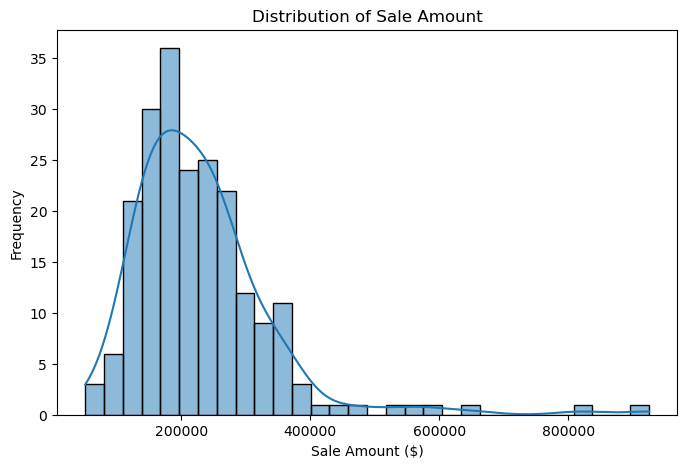

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(myData['Sale_amount'], kde=True, bins=30)
plt.title('Distribution of Sale Amount')
plt.xlabel('Sale Amount ($)')
plt.ylabel('Frequency')
plt.show()


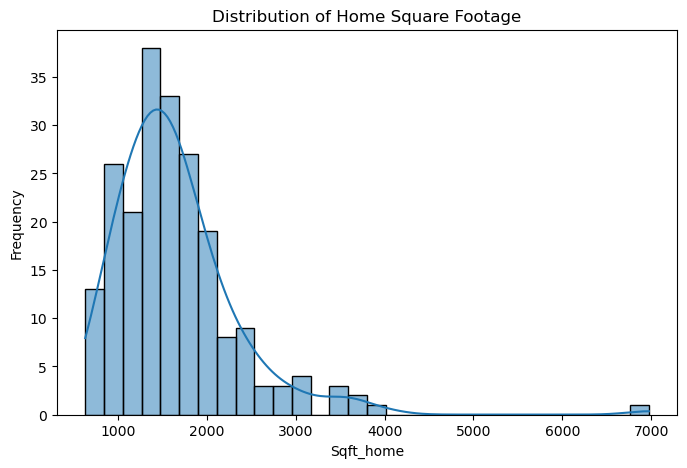

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(myData['Sqft_home'], kde=True, bins=30)
plt.title('Distribution of Home Square Footage')
plt.xlabel('Sqft_home')
plt.ylabel('Frequency')
plt.show()

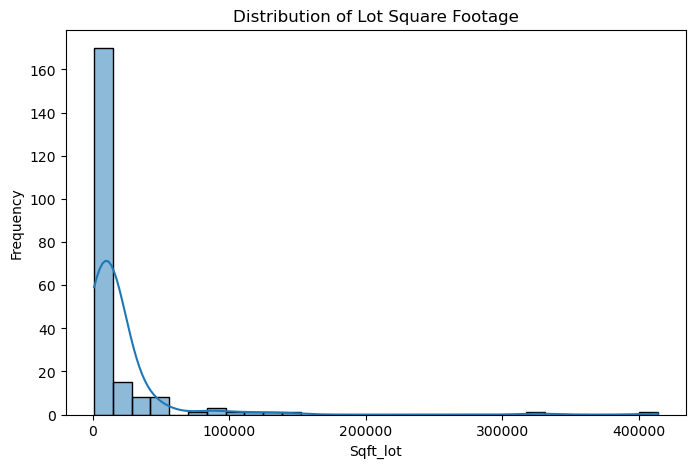

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(myData['Sqft_lot'], kde=True, bins=30)
plt.title('Distribution of Lot Square Footage')
plt.xlabel('Sqft_lot')
plt.ylabel('Frequency')
plt.show()


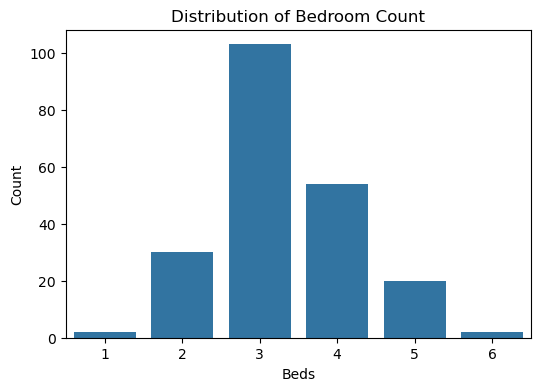

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=myData['Beds'])
plt.title('Distribution of Bedroom Count')
plt.xlabel('Beds')
plt.ylabel('Count')
plt.show()

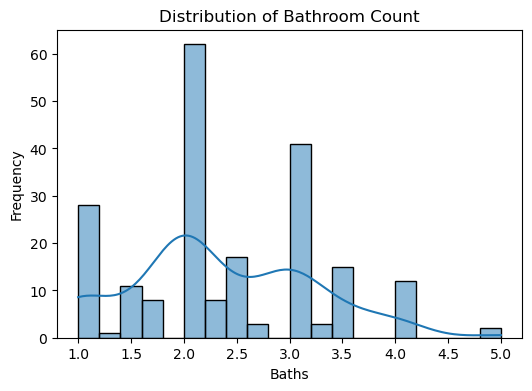

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(myData['Baths'], kde=True, bins=20)
plt.title('Distribution of Bathroom Count')
plt.xlabel('Baths')
plt.ylabel('Frequency')
plt.show()


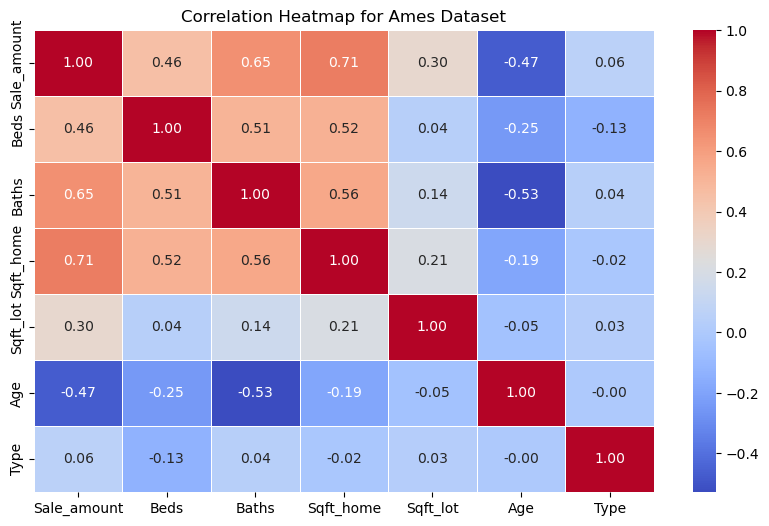

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = myData[['Sale_amount', 'Beds', 'Baths', 'Sqft_home', 'Sqft_lot', 'Age', 'Type']].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap for Ames Dataset')
plt.show()

### Model 1: Sale_amount ~ Beds + Baths + Sqft_home + Sqft_lot + Type + Age

                            OLS Regression Results                            
Dep. Variable:            Sale_amount   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     69.36
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.35e-46
Time:                        20:23:59   Log-Likelihood:                -2632.2
No. Observations:                 211   AIC:                             5278.
Df Residuals:                     204   BIC:                             5302.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4366.8347   5.31e+04      0.082      0.9

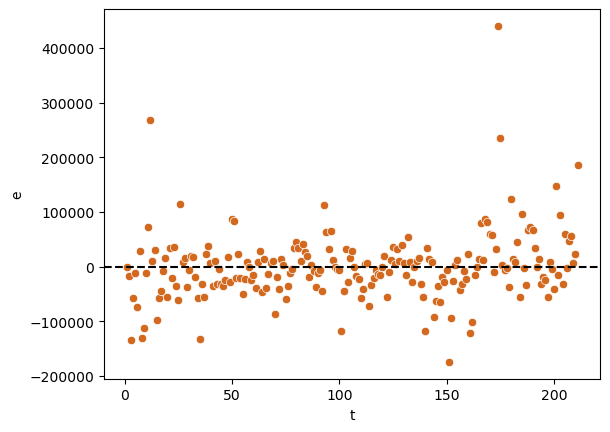

                            OLS Regression Results                            
Dep. Variable:            Sale_amount   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     45.76
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           3.05e-35
Time:                        20:24:00   Log-Likelihood:                -2632.2
No. Observations:                 211   AIC:                             5278.
Df Residuals:                     204   BIC:                             5302.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4366.8347   3.03e+04      0.144      0.8

In [38]:
# Obtaining regression equation using all predictor variables
import statsmodels.formula.api as smf
import numpy as np

Model1 = smf.ols('Sale_amount ~ Beds + Baths + Sqft_home + Sqft_lot + Type + Age', data = myData).fit()

print(Model1.summary())

# Obtaining residuals
Model_Residuals = Model1.resid

import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.scatterplot(x =myData.Record, y = Model_Residuals, color = 'Chocolate')

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--')

# Set labels
ax.set(xlabel = 't', ylabel ='e');

# Show the plot
plt.show()

#Calculating robust standard error
Robust_Results = Model1.get_robustcov_results(cov_type = 'HAC', maxlags = None, use_correction = True)
print(Robust_Results.summary())
print('\n')
print('Standard Error of Estimate:', np.sqrt(Model1.mse_resid))

### Model 2: Sale_amount ~ Baths + Sqft_home + Sqft_lot + Age

                            OLS Regression Results                            
Dep. Variable:            Sale_amount   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     103.1
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           4.56e-48
Time:                        20:24:00   Log-Likelihood:                -2633.5
No. Observations:                 211   AIC:                             5277.
Df Residuals:                     206   BIC:                             5294.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8.172e+04   2.13e+04      3.836      0.0

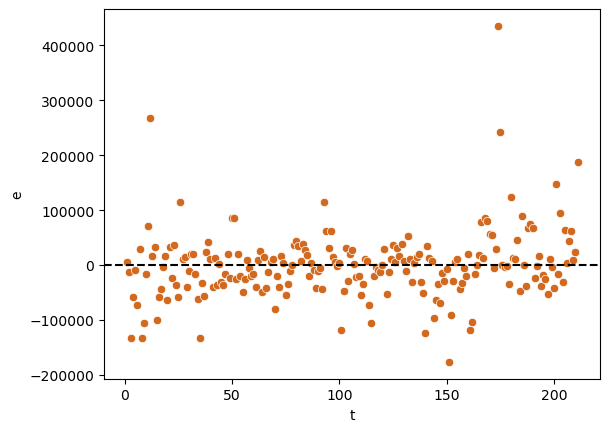

                            OLS Regression Results                            
Dep. Variable:            Sale_amount   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     50.25
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.80e-29
Time:                        20:24:00   Log-Likelihood:                -2633.5
No. Observations:                 211   AIC:                             5277.
Df Residuals:                     206   BIC:                             5294.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8.172e+04   1.51e+04      5.426      0.0

In [39]:
# Obtatining linear regression equation with statiscally significant variables
Model2 = smf.ols('Sale_amount ~ Baths + Sqft_home + Sqft_lot + Age', data = myData).fit()
print(Model2.summary())

# Obtaining residuals
Model_Residuals = Model2.resid

import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.scatterplot(x =myData.Record, y = Model_Residuals, color = 'Chocolate')

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--')

# Set labels
ax.set(xlabel = 't', ylabel ='e');

# Show the plot
plt.show()

#Calculating robust standard error
Robust_Results = Model2.get_robustcov_results(cov_type = 'HAC', maxlags = None, use_correction = True)
print(Robust_Results.summary())
print('\n')
print('Standard Error of Estimate:', np.sqrt(Model2.mse_resid))

### Model 3: ln(Sale_amount) ~ Baths + ln(Sqft_home) + ln(Sqft_lot) + Age

                             OLS Regression Results                            
Dep. Variable:     np.log(Sale_amount)   R-squared:                       0.751
Model:                             OLS   Adj. R-squared:                  0.747
Method:                  Least Squares   F-statistic:                     155.7
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           4.21e-61
Time:                         20:24:00   Log-Likelihood:                 30.223
No. Observations:                  211   AIC:                            -50.45
Df Residuals:                      206   BIC:                            -33.69
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.7199

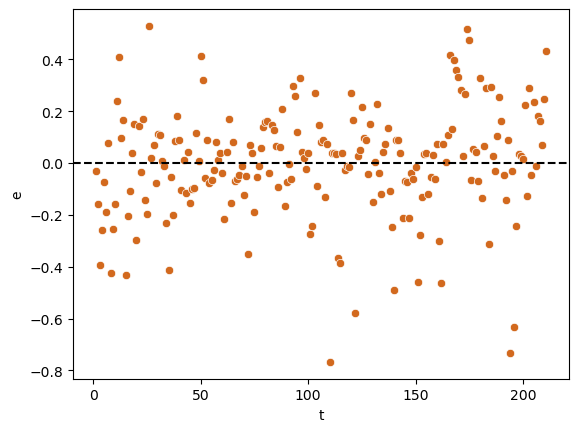

                             OLS Regression Results                            
Dep. Variable:     np.log(Sale_amount)   R-squared:                       0.751
Model:                             OLS   Adj. R-squared:                  0.747
Method:                  Least Squares   F-statistic:                     73.69
Date:                 Thu, 04 Dec 2025   Prob (F-statistic):           1.14e-38
Time:                         20:24:00   Log-Likelihood:                 30.223
No. Observations:                  211   AIC:                            -50.45
Df Residuals:                      206   BIC:                            -33.69
Df Model:                            4                                         
Covariance Type:                   HAC                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.7199

In [40]:
# Obtatining linear regression equation with statiscally significant variables and apply logarithmic transformation for large values
Model3 = smf.ols('np.log(Sale_amount) ~ Baths + np.log(Sqft_home) + np.log(Sqft_lot) + Age', data = myData).fit()
print(Model3.summary())

# Obtaining residuals
Model_Residuals = Model3.resid

import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.scatterplot(x =myData.Record, y = Model_Residuals, color = 'Chocolate')

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--')

# Set labels
ax.set(xlabel = 't', ylabel ='e');

# Show the plot
plt.show()

#Calculating robust standard error
Robust_Results = Model3.get_robustcov_results(cov_type = 'HAC', maxlags = None, use_correction = True)
print(Robust_Results.summary())
print('\n')
print('Standard Error of Estimate:', np.sqrt(Model3.mse_resid))

### Cross Validation of All Models

In [41]:
# Evaluation
# K-fold validation method where k = 10
from sklearn.model_selection import KFold
splits = KFold(n_splits=10, shuffle=False).split(myData)
RMSE1 = []
RMSE2 = []
RMSE3 = []

MAE1 = []
MAE2 = []
MAE3 = []

MAPE1 = []
MAPE2 = []
MAPE3 = []

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

for train_index, val_index in splits:
    TData, VData = myData.iloc[train_index], myData.iloc[val_index]
    
    model1 = smf.ols('Sale_amount ~ Beds + Baths + Sqft_home + Sqft_lot + Type + Age', data=TData).fit()
    pred1 = model1.predict(VData)
    rmse1 = np.sqrt(mean_squared_error(VData['Sale_amount'], pred1))
    mae1 = mean_absolute_error(VData['Sale_amount'], pred1)
    mape1 = mean_absolute_percentage_error(VData['Sale_amount'], pred1)
    RMSE1.append(rmse1)
    MAE1.append(mae1)
    MAPE1.append(mape1)
    
    model2 = smf.ols('Sale_amount ~ Baths + Sqft_home + Sqft_lot + Age', data=TData).fit()
    pred2 = model2.predict(VData)
    rmse2 = np.sqrt(mean_squared_error(VData['Sale_amount'], pred2))
    mae2 = mean_absolute_error(VData['Sale_amount'], pred2)
    mape2 = mean_absolute_percentage_error(VData['Sale_amount'], pred2)
    RMSE2.append(rmse2)
    MAE2.append(mae2)
    MAPE2.append(mape2)

    model3 = smf.ols('np.log(Sale_amount) ~ Baths + np.log(Sqft_home) + np.log(Sqft_lot) + Age', data=TData).fit()
    pred3 = np.exp(model3.predict(VData))
    rmse3 = np.sqrt(mean_squared_error(VData['Sale_amount'], pred3))
    mae3 = mean_absolute_error(VData['Sale_amount'], pred3)
    mape3 = mean_absolute_percentage_error(VData['Sale_amount'], pred3)
    RMSE3.append(rmse3)
    MAE3.append(mae3)
    MAPE3.append(mape3)

rmse1 = np.mean(RMSE1)
rmse2 = np.mean(RMSE2)
rmse3 = np.mean(RMSE3)

mae1 = np.mean(MAE1)
mae2 = np.mean(MAE2)
mae3 = np.mean(MAE3)

mape1 = np.mean(MAPE1)
mape2 = np.mean(MAPE2)
mape3 = np.mean(MAPE3)

print('Model 1 RMSE:', rmse1)
print('Model 1 MAE:', mae1)
print('Model 1 MAPE:', mape1)
print('\n')
print('Model 2 RMSE:', rmse2)
print('Model 2 MAE:', mae2)
print('Model 2 MAPE:', mape2)
print('\n')
print('Model 3 RMSE:', rmse3)
print('Model 3 MAE:', mae3)
print('Model 3 MAPE:', mape3)

Model 1 RMSE: 65029.86318307983
Model 1 MAE: 45056.79960278114
Model 1 MAPE: 0.19513181470440719


Model 2 RMSE: 64834.33582904884
Model 2 MAE: 44709.80604016928
Model 2 MAPE: 0.19418547298323804


Model 3 RMSE: 56677.49727330621
Model 3 MAE: 39895.531525147846
Model 3 MAPE: 0.1698296307676635


## Ensemble Tree Models

In [42]:
myData = pd.read_excel('D:/Appendix_A_data.xlsx', sheet_name = 'House_Price')

myData.head()

,Record,Sale_amount,Sale_date,Beds,Baths,Sqft_home,Sqft_lot,Type,Build_year,Town,University
0,1,295000,2016-05-31,5,3.00,2020,38332.8,Single Family,1976,"Ames, IA",Iowa State University
1,2,240000,2016-06-20,4,2.00,1498,54014.4,Single Family,2002,"Ames, IA",Iowa State University
2,3,385000,2016-05-31,5,4.00,4000,85813.2,Single Family,2001,"Ames, IA",Iowa State University
3,4,268000,2016-04-12,3,2.50,2283,118918.8,Single Family,1972,"Ames, IA",Iowa State University
4,5,186000,2016-04-05,3,1.25,1527,15681.6,Single Family,1975,"Ames, IA",Iowa State University


In [43]:
# Filter dataset for Iowa State University
myData = myData.query("University =='Iowa State University'")

# Convert house type into dummy variable, Single Family = 1, Non Single Family = 0
myData['Type'] = myData['Type'].apply(lambda x: 1 if x == 'Single Family' else 0)

# Determining age of home
from datetime import datetime
myData['Age'] = datetime.now().year - myData['Build_year']

# Drop town and university columns and all categorial variable columns with more than two values
myData = myData.drop(['Record', 'Sale_date', 'Build_year', 'Town', 'University'], axis=1)

myData.head()

,Sale_amount,Beds,Baths,Sqft_home,Sqft_lot,Type,Age
0,295000,5,3.00,2020,38332.8,1,49
1,240000,4,2.00,1498,54014.4,1,23
2,385000,5,4.00,4000,85813.2,1,24
3,268000,3,2.50,2283,118918.8,1,53
4,186000,3,1.25,1527,15681.6,1,50


In [44]:
# 70% training, 30% test, random state 321
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(myData.drop('Sale_amount', axis = 1), 
                                                    myData.Sale_amount, 
                                                    test_size = 0.30, 
                                                    random_state = 321)

# Look if split is correct
print(len(X_train))
print(len(X_test))

147
64


### Model 1: Bagging Tree

In [45]:
# Random forest regressor for ensemble trees
from sklearn.ensemble import RandomForestRegressor

Bagging_model = RandomForestRegressor(random_state = 321)

# Bagging tree parameters
paramGrid = {'n_estimators': [100, 250, 500, 1000], 
             'max_depth': range(1, 10 + 1), 
             'max_features': [None]}

# 10 fold validation
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(Bagging_model, 
                      paramGrid, 
                      cv = 10, 
                      scoring = 'neg_root_mean_squared_error', 
                      n_jobs = -1)

In [46]:
Bagging_tree = search.fit(X_train, y_train)
pd.DataFrame(Bagging_tree.cv_results_).sort_values('rank_test_score')[['param_n_estimators', 'param_max_depth','mean_test_score', 'rank_test_score']].head(10)

,param_n_estimators,param_max_depth,mean_test_score,rank_test_score
34,500,9,-62934.869503,1
32,100,9,-62964.796114,2
35,1000,9,-63004.242075,3
38,500,10,-63023.737570,4
39,1000,10,-63039.976138,5
36,100,10,-63126.952901,6
28,100,8,-63164.766899,7
30,500,8,-63218.684164,8
33,250,9,-63284.955959,9
31,1000,8,-63343.455919,10


In [47]:
Bagging_tree.best_estimator_

RandomForestRegressor(max_depth=9, max_features=None, n_estimators=500,
                      random_state=321)

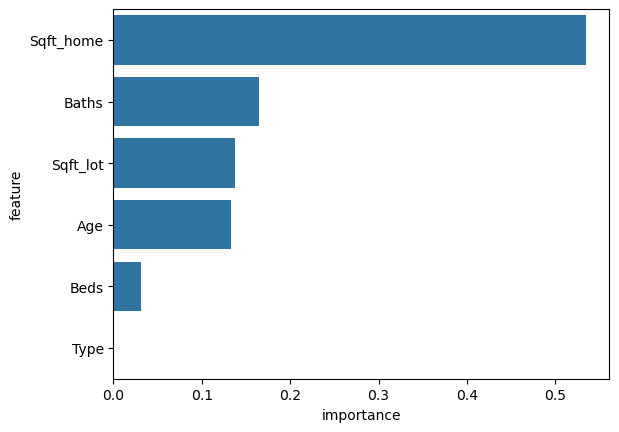

In [48]:
importances = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': Bagging_tree.best_estimator_.feature_importances_
})

import seaborn as sns
sns.barplot(y = 'feature', 
            x = 'importance', 
            data = importances.sort_values('importance', ascending = False));

In [49]:
# Evaluation
testPredictions = Bagging_tree.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print('RMSE:', np.sqrt(mean_squared_error(y_test, testPredictions)))
print('MAE:', mean_absolute_error(y_test, testPredictions))
print('MAPE:', mean_absolute_percentage_error(y_test, testPredictions))

RMSE: 64555.78973220282
MAE: 39467.92781633769
MAPE: 0.17397341543932393


### Model 2: Random Forest

In [50]:
# Random forest regressor for ensemble trees
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor(random_state = 321)

# Random Forest parameters
paramGrid = {'n_estimators': [100, 250, 500, 1000], 
             'max_depth': range(1, 10 + 1), 
             'max_features': ["sqrt"]}

# 10 fold validation
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(RF_model, 
                      paramGrid, 
                      cv = 10, 
                      scoring = 'neg_root_mean_squared_error', 
                      n_jobs = -1)

In [51]:
RF_tree = search.fit(X_train, y_train)
pd.DataFrame(RF_tree.cv_results_).sort_values('rank_test_score')[['param_n_estimators', 'param_max_depth','mean_test_score', 'rank_test_score']].head(10)

,param_n_estimators,param_max_depth,mean_test_score,rank_test_score
32,100,9,-62723.146281,1
28,100,8,-63285.617710,2
36,100,10,-63599.803428,3
38,500,10,-63607.807353,4
39,1000,10,-63694.804779,5
37,250,10,-63842.910451,6
29,250,8,-63849.510373,7
35,1000,9,-64108.626466,8
34,500,9,-64121.828382,9
27,1000,7,-64201.640787,10


In [52]:
RF_tree.best_estimator_

RandomForestRegressor(max_depth=9, max_features='sqrt', random_state=321)

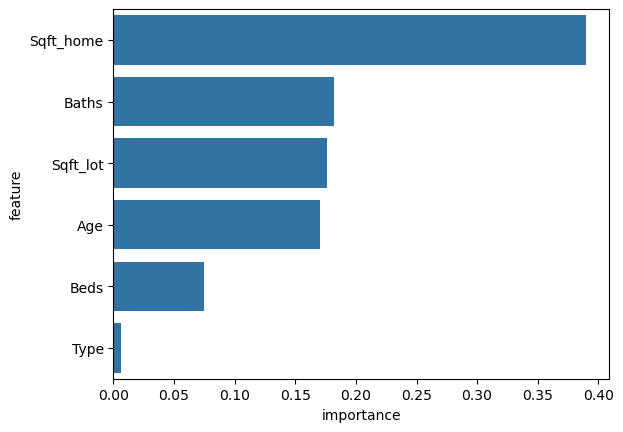

In [53]:
importances = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': RF_tree.best_estimator_.feature_importances_
})

import seaborn as sns
sns.barplot(y = 'feature', 
            x = 'importance', 
            data = importances.sort_values('importance', ascending = False));

In [54]:
# Evaluation
testPredictions = RF_tree.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print('RMSE:', np.sqrt(mean_squared_error(y_test, testPredictions)))
print('MAE:', mean_absolute_error(y_test, testPredictions))
print('MAPE:', mean_absolute_percentage_error(y_test, testPredictions))

RMSE: 57218.84034332497
MAE: 36001.76788943625
MAPE: 0.16368823528219234


### Model 3: Boosting Tree

In [55]:
from sklearn.ensemble import GradientBoostingRegressor

Boosting_model = GradientBoostingRegressor(random_state = 321)

paramGrid = {'n_estimators': [100, 250, 500, 1000], 
             'max_depth': range(1, 10 + 1)}

from sklearn.model_selection import GridSearchCV

search = GridSearchCV(Boosting_model, 
                      paramGrid, 
                      cv = 10, 
                      scoring = 'neg_root_mean_squared_error', 
                      n_jobs = -1)

In [56]:
Boosting_tree = search.fit(X_train, y_train)
pd.DataFrame(Boosting_tree.cv_results_).sort_values('rank_test_score')[['param_n_estimators', 'param_max_depth','mean_test_score', 'rank_test_score']].head(10)

,param_n_estimators,param_max_depth,mean_test_score,rank_test_score
4,100,2,-62270.226529,1
5,250,2,-63660.262063,2
6,500,2,-65292.378273,3
0,100,1,-65499.591026,4
7,1000,2,-65985.371333,5
13,250,4,-67511.882487,6
15,1000,4,-67512.170360,7
14,500,4,-67513.258146,8
12,100,4,-67734.575497,9
1,250,1,-68290.084379,10


In [57]:
Boosting_tree.best_estimator_

GradientBoostingRegressor(max_depth=2, random_state=321)

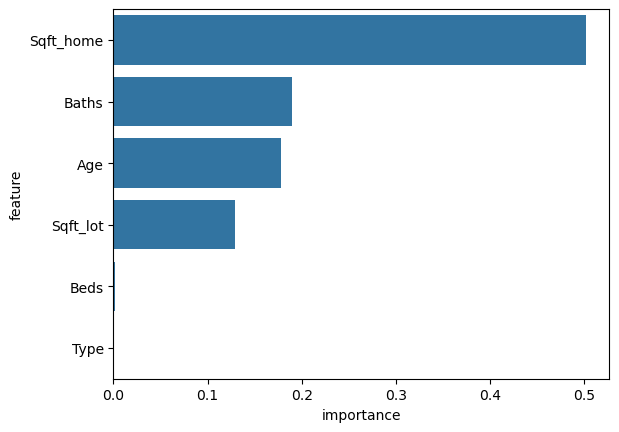

In [58]:
importances = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': Boosting_tree.best_estimator_.feature_importances_
})

import seaborn as sns
sns.barplot(y = 'feature', 
            x = 'importance', 
            data = importances.sort_values('importance', ascending = False));

In [59]:
# Evaluation
testPredictions = Boosting_tree.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print('RMSE:', np.sqrt(mean_squared_error(y_test, testPredictions)))
print('MAE:', mean_absolute_error(y_test, testPredictions))
print('MAPE:', mean_absolute_percentage_error(y_test, testPredictions))

RMSE: 76603.7896692011
MAE: 42463.15736203704
MAPE: 0.1822608656890588
